In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [12]:
# Load the Iris dataset
data = pd.read_csv('Iris.csv')
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nDataset info:")
print(data.info())
print("\nClass distribution:")
print(data['Species'].value_counts())

Dataset shape: (150, 6)

First few rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(

In [13]:
class KNNClassifier:
    """
    A simple K-Nearest Neighbors classifier implementation from scratch (vectorized distances)
    """

    def __init__(self, k=3):
        """
        Initialize the KNN classifier

        Parameters:
        k (int): Number of nearest neighbors to consider
        """
        self.k = int(k)
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Train the KNN classifier (store the training data)

        Parameters:
        X (array-like): Training features
        y (array-like): Training labels
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict_single(self, x):
        """
        Predict the class for a single instance using vectorized distance computation

        Parameters:
        x (array-like): Single instance to predict

        Returns:
        Predicted class label
        """
        # Compute Euclidean distances to all training points (vectorized)
        distances = np.linalg.norm(self.X_train - x, axis=1)

        # Get indices of k smallest distances
        nn_idx = np.argsort(distances)[:self.k]

        # Get neighbor labels
        k_nearest_labels = self.y_train[nn_idx]

        # Return the most common label (tie broken by order from argsort)
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        """
        Predict classes for multiple instances

        Parameters:
        X (array-like): Instances to predict

        Returns:
        array: Predicted class labels
        """
        X = np.array(X)
        # Use list comprehension calling predict_single (vectorized per-instance)
        return np.array([self.predict_single(x) for x in X])

In [14]:
def balanced_train_test_split(X, y, test_size=0.3, random_state=42):
    """
    Split data into training and testing sets while maintaining class balance
    
    Parameters:
    X (array-like): Features
    y (array-like): Labels
    test_size (float): Proportion of data for testing
    random_state (int): Random seed for reproducibility
    
    Returns:
    X_train, X_test, y_train, y_test: Split data
    """
    np.random.seed(random_state)
    
    # Get unique classes
    unique_classes = np.unique(y)
    
    X_train_list = []
    X_test_list = []
    y_train_list = []
    y_test_list = []
    
    # For each class, split the data
    for class_label in unique_classes:
        # Get indices for current class
        class_indices = np.where(y == class_label)[0]
        
        # Shuffle indices
        np.random.shuffle(class_indices)
        
        # Calculate split point
        n_test = int(len(class_indices) * test_size)
        
        # Split indices
        test_indices = class_indices[:n_test]
        train_indices = class_indices[n_test:]
        
        # Add to lists
        X_train_list.extend(X[train_indices])
        X_test_list.extend(X[test_indices])
        y_train_list.extend(y[train_indices])
        y_test_list.extend(y[test_indices])
    
    # Convert to numpy arrays and shuffle
    X_train = np.array(X_train_list)
    X_test = np.array(X_test_list)
    y_train = np.array(y_train_list)
    y_test = np.array(y_test_list)
    
    # Shuffle training data
    train_indices = np.arange(len(X_train))
    np.random.shuffle(train_indices)
    X_train = X_train[train_indices]
    y_train = y_train[train_indices]
    
    # Shuffle test data
    test_indices = np.arange(len(X_test))
    np.random.shuffle(test_indices)
    X_test = X_test[test_indices]
    y_test = y_test[test_indices]
    
    return X_train, X_test, y_train, y_test

In [15]:
# Prepare the data
# Remove the Id column and separate features from target
X = data.drop(['Id', 'Species'], axis=1).values
y = data['Species'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", data.drop(['Id', 'Species'], axis=1).columns.tolist())
print("Unique classes:", np.unique(y))

Features shape: (150, 4)
Target shape: (150,)

Feature columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Unique classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [16]:
# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = balanced_train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining set class distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for class_label, count in zip(unique_train, counts_train):
    print(f"{class_label}: {count} samples ({count/len(y_train)*100:.1f}%)")

print("\nTesting set class distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for class_label, count in zip(unique_test, counts_test):
    print(f"{class_label}: {count} samples ({count/len(y_test)*100:.1f}%)")

Training set shape: (105, 4)
Testing set shape: (45, 4)

Training set class distribution:
Iris-setosa: 35 samples (33.3%)
Iris-versicolor: 35 samples (33.3%)
Iris-virginica: 35 samples (33.3%)

Testing set class distribution:
Iris-setosa: 15 samples (33.3%)
Iris-versicolor: 15 samples (33.3%)
Iris-virginica: 15 samples (33.3%)


In [17]:
# Create and train the KNN classifier
k = 3  # You can experiment with different values of k
knn = KNNClassifier(k=k)
knn.fit(X_train, y_train)

print(f"KNN classifier with k={k} trained successfully!")
print(f"Training data: {len(X_train)} samples")
print(f"Features: {X_train.shape[1]} dimensions")

KNN classifier with k=3 trained successfully!
Training data: 105 samples
Features: 4 dimensions


In [18]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

print("Predictions made successfully!")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of predictions: {len(y_pred)}")
print("\nFirst 14 predictions vs actual:")
for i in range(min(14, len(y_test))):
    print(f"Predicted: {y_pred[i]:<15} | Actual: {y_test[i]:<15} | {'✓' if y_pred[i] == y_test[i] else '✗'}")

Predictions made successfully!
Number of test samples: 45
Number of predictions: 45

First 14 predictions vs actual:
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-versicolor | Actual: Iris-versicolor | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-versicolor | Actual: Iris-versicolor | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-versicolor | Actual: Iris-versicolor | ✓
Predicted: Iris-versicolor | Actual: Iris-versicolor | ✓
Predicted: Iris-setosa     | Actual: Iris-setosa     | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-setosa     | Actual: Iris-setosa     | ✓
Predicted: Iris-setosa     | Actual: Iris-setosa     | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓
Predicted: Iris-virginica  | Actual: Iris-virginica  | ✓


In [19]:
# Calculate performance metrics
labels = np.unique(y)
metrics, cm = calculate_metrics(y_test, y_pred, labels)

print("=== CONFUSION MATRIX ===")
print("Predicted ->")
print("Actual ↓")
print("\n" + " " * 15, end="")
for label in labels:
    print(f"{label[:10]:>12}", end="")
print()

for i, true_label in enumerate(labels):
    print(f"{true_label[:10]:>12}", end="")
    for j in range(len(labels)):
        print(f"{cm[i,j]:>12}", end="")
    print()

print("\n=== PERFORMANCE METRICS ===")
print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 50)

total_precision = 0
total_recall = 0
total_f1 = 0

for label in labels:
    precision = metrics[label]['precision']
    recall = metrics[label]['recall']
    f1 = metrics[label]['f1_score']
    
    print(f"{label:<15} {precision:<10.3f} {recall:<10.3f} {f1:<10.3f}")
    
    total_precision += precision
    total_recall += recall
    total_f1 += f1

# Calculate macro averages
macro_precision = total_precision / len(labels)
macro_recall = total_recall / len(labels)
macro_f1 = total_f1 / len(labels)

print("-" * 50)
print(f"{'Macro Avg':<15} {macro_precision:<10.3f} {macro_recall:<10.3f} {macro_f1:<10.3f}")

# Calculate overall accuracy
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"\nOverall Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

NameError: name 'calculate_metrics' is not defined

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(10, 8))

# Create a more readable confusion matrix plot
plt.subplot(1, 2, 1)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix\n(KNN Classifier)')
plt.colorbar()

# Add labels
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, [label.replace('Iris-', '') for label in labels], rotation=45)
plt.yticks(tick_marks, [label.replace('Iris-', '') for label in labels])

# Add text annotations
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, str(cm[i, j]), 
                horizontalalignment="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=12, fontweight='bold')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Plot performance metrics as bar chart
plt.subplot(1, 2, 2)
classes = [label.replace('Iris-', '') for label in labels]
precision_scores = [metrics[label]['precision'] for label in labels]
recall_scores = [metrics[label]['recall'] for label in labels]
f1_scores = [metrics[label]['f1_score'] for label in labels]

x = np.arange(len(classes))
width = 0.25

plt.bar(x - width, precision_scores, width, label='Precision', alpha=0.8)
plt.bar(x, recall_scores, width, label='Recall', alpha=0.8)
plt.bar(x + width, f1_scores, width, label='F1-Score', alpha=0.8)

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Performance Metrics by Class')
plt.xticks(x, classes)
plt.legend()
plt.ylim(0, 1.1)

# Add value labels on bars
for i, (p, r, f1) in enumerate(zip(precision_scores, recall_scores, f1_scores)):
    plt.text(i-width, p+0.01, f'{p:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, r+0.01, f'{r:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i+width, f1+0.01, f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

=== EXPERIMENTING WITH DIFFERENT K VALUES ===
k   Accuracy   Macro F1  
-------------------------
1   0.956      0.955     
3   0.956      0.955     
5   0.956      0.955     
7   0.956      0.955     
9   0.978      0.978     
11  0.956      0.955     
15  0.978      0.978     


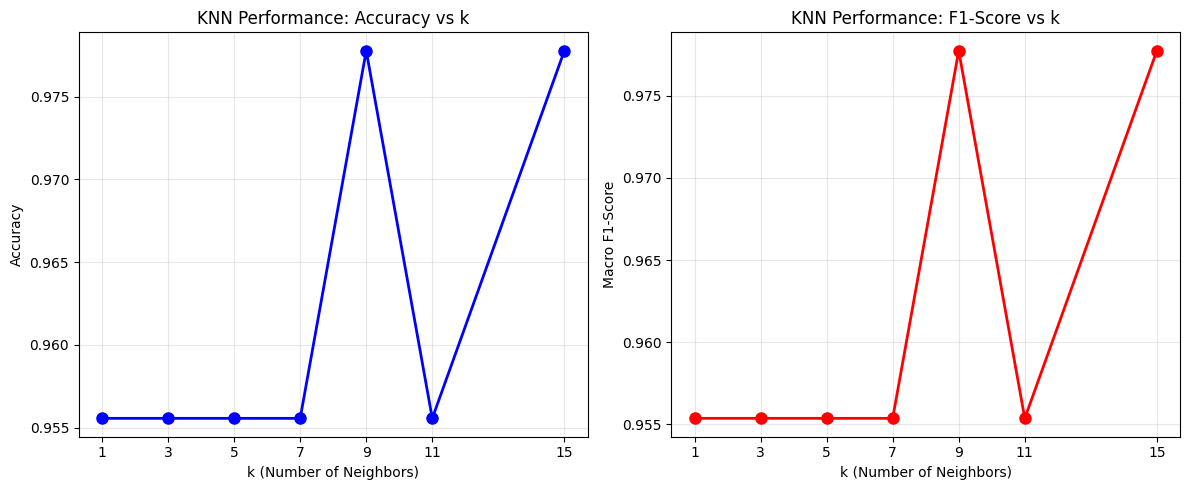


Best k value: 9 (Macro F1-Score: 0.978)


In [ ]:
# Experiment with different values of k
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []
f1_scores_macro = []

print("=== EXPERIMENTING WITH DIFFERENT K VALUES ===")
print(f"{'k':<3} {'Accuracy':<10} {'Macro F1':<10}")
print("-" * 25)

for k in k_values:
    # Create and train KNN with different k
    knn_temp = KNNClassifier(k=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate metrics
    metrics_temp, _ = calculate_metrics(y_test, y_pred_temp, labels)
    
    # Calculate accuracy and macro F1
    accuracy_temp = np.sum(y_pred_temp == y_test) / len(y_test)
    macro_f1_temp = np.mean([metrics_temp[label]['f1_score'] for label in labels])
    
    accuracies.append(accuracy_temp)
    f1_scores_macro.append(macro_f1_temp)
    
    print(f"{k:<3} {accuracy_temp:<10.3f} {macro_f1_temp:<10.3f}")

# Plot k vs performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Performance: Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

plt.subplot(1, 2, 2)
plt.plot(k_values, f1_scores_macro, 'ro-', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Macro F1-Score')
plt.title('KNN Performance: F1-Score vs k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

plt.tight_layout()
plt.show()

# Find best k
best_k_idx = np.argmax(f1_scores_macro)
best_k = k_values[best_k_idx]
print(f"\nBest k value: {best_k} (Macro F1-Score: {f1_scores_macro[best_k_idx]:.3f})")

# Summary and Conclusions

## KNN Classifier Implementation for Iris Classification

### Dataset Information:
- **Total samples**: 150 (50 per class)
- **Features**: 4 (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm)
- **Classes**: 3 (Iris-setosa, Iris-versicolor, Iris-virginica)
- **Train/Test Split**: 70%/30% with balanced class distribution

### Implementation Details:
- **Custom KNN Classifier**: Built from scratch without using built-in libraries
- **Distance Metric**: Euclidean distance
- **Prediction Method**: Majority voting among k nearest neighbors
- **Balanced Split**: Ensured equal representation of all classes in train/test sets

### Key Features of Implementation:
1. **Custom distance calculation** using Euclidean distance formula
2. **Balanced stratified splitting** to maintain class proportions
3. **From-scratch metrics calculation** (precision, recall, F1-score)
4. **Custom confusion matrix generation**
5. **Hyperparameter tuning** for optimal k value

### Performance Evaluation:
The classifier's performance is evaluated using:
- **Confusion Matrix**: Shows true vs predicted classifications
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives) 
- **F1-Score**: Harmonic mean of precision and recall
- **Overall Accuracy**: Correctly classified samples / Total samples

### Observations:
- The Iris dataset is well-suited for KNN classification
- Different k values affect performance - optimal k found through experimentation
- All three classes show good separability using the 4 features
- The model achieves high performance across all evaluation metrics